- Save figures as PDF
- Take out the figure title from the figures(keep it as caption in Latex)
- Font size: x and y axis size 24 bolded(x and y axis title mandatory)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
pip install ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 49.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ucimlrepo]/3 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# metadata
print(statlog_german_credit_data.metadata)

# variable information
print(statlog_german_credit_data.variables)
# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

# Verify the shape (should have 21 columns: 20 features + 1 target)
print(df.shape)
df.head()

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
# data mapping for simplicity
column_mapping = {
    "Attribute1": "checking_account_status",
    "Attribute2": "duration_months",
    "Attribute3": "credit_history",
    "Attribute4": "purpose",
    "Attribute5": "credit_amount",
    "Attribute6": "savings_account",
    "Attribute7": "employment_duration",
    "Attribute8": "installment_rate",
    "Attribute9": "sex",
    "Attribute10": "other_debtors",
    "Attribute11": "residence_duration",
    "Attribute12": "property",
    "Attribute13": "age",
    "Attribute14": "other_installment_plans",
    "Attribute15": "housing",
    "Attribute16": "existing_credits",
    "Attribute17": "job",
    "Attribute18": "num_dependents",
    "Attribute19": "telephone",
    "Attribute20": "foreign_worker",
    "class": "target"
}

checking_account_status_map = {
    "A11": "... < 0 DM",
    "A12": "0 <= ... < 200 DM",
    "A13": "... >= 200 DM / salary assignments for at least 1 year",
    "A14": "no checking account"
}

credit_history_map = {
    "A30": "no credits taken / all credits paid back duly",
    "A31": "all credits at this bank paid back duly",
    "A32": "existing credits paid back duly till now",
    "A33": "delay in paying off in the past",
    "A34": "critical account / other credits existing (not at this bank)"
}

purpose_map = {
    "A40": "car (new)",
    "A41": "car (used)",
    "A42": "furniture/equipment",
    "A43": "radio/television",
    "A44": "domestic appliances",
    "A45": "repairs",
    "A46": "education",
    "A47": "vacation",
    "A48": "retraining",
    "A49": "business",
    "A410": "others"
}

savings_account_map = {
    "A61": "... < 100 DM",
    "A62": "100 <= ... < 500 DM",
    "A63": "500 <= ... < 1000 DM",
    "A64": "... >= 1000 DM",
    "A65": "unknown / no savings account"
}

employment_duration_map = {
    "A71": "unemployed",
    "A72": "... < 1 year",
    "A73": "1 <= ... < 4 years",
    "A74": "4 <= ... < 7 years",
    "A75": "... >= 7 years"
}

personal_status_sex_map = {
    "A91": "male : divorced/separated",
    "A92": "female : divorced/separated/married",
    "A93": "male : single",
    "A94": "male : married/widowed",
    "A95": "female : single"
}

other_debtors_map = {
    "A101": "none",
    "A102": "co-applicant",
    "A103": "guarantor"
}

property_map = {
    "A121": "real estate",
    "A122": "building society savings agreement / life insurance",
    "A123": "car or other, not in savings account",
    "A124": "unknown / no property"
}

other_installment_plans_map = {
    "A141": "bank",
    "A142": "stores",
    "A143": "none"
}

housing_map = {
    "A151": "rent",
    "A152": "own",
    "A153": "for free"
}

job_map = {
    "A171": "unemployed / unskilled - non-resident",
    "A172": "unskilled - resident",
    "A173": "skilled employee / official",
    "A174": "management / self-employed / highly qualified employee / officer"
}

telephone_map = {
    "A191": "none",
    "A192": "yes, registered under customer's name"
}

foreign_worker_map = {
    "A201": "yes",
    "A202": "no"
}
df = df.rename(columns=column_mapping)
df["checking_account_status"] = df["checking_account_status"].map(checking_account_status_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_account_map)
df["employment_duration"] = df["employment_duration"].map(employment_duration_map)
df["sex"] = df["sex"].map(personal_status_sex_map)
df["other_debtors"] = df["other_debtors"].map(other_debtors_map)
df["property"] = df["property"].map(property_map)
df["other_installment_plans"] = df["other_installment_plans"].map(other_installment_plans_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)
df["telephone"] = df["telephone"].map(telephone_map)
df["foreign_worker"] = df["foreign_worker"].map(foreign_worker_map)
# checking_map = {
#     "A11": "< 0 DM",
#     "A12": "0–200 DM",
#     "A13": "≥ 200 DM",
#     "A14": "no account"
# }
# credit_history_map = {
#     "A30": "no credits",
#     "A31": "all paid",
#     "A32": "existing paid",
#     "A33": "delay in past",
#     "A34": "critical account"
# }
# purpose_map = {
#     "A40": "car (new)",
#     "A41": "car (used)",
#     "A42": "furniture/equipment",
#     "A43": "radio/TV",
#     "A44": "domestic appliances",
#     "A45": "repairs",
#     "A46": "education",
#     "A47": "vacation",
#     "A48": "retraining",
#     "A49": "business",
#     "A410": "others"
# }
# savings_map = {
#     "A61": "< 100 DM",
#     "A62": "100–500 DM",
#     "A63": "500–1000 DM",
#     "A64": "≥ 1000 DM",
#     "A65": "unknown / none"
# }
# employment_map = {
#     "A71": "unemployed",
#     "A72": "< 1 year",
#     "A73": "1–4 years",
#     "A74": "4–7 years",
#     "A75": "≥ 7 years"
# }
# personal_status_sex_map = {
#     "A91": "male divorced/separated",
#     "A92": "female divorced/married",
#     "A93": "male single",
#     "A94": "male married/widowed",
#     "A95": "female single"
# }
# df = df.rename(columns=column_mapping)
# df["checking_account_status"] = df["checking_account_status"].map(checking_map)
# df["credit_history"] = df["credit_history"].map(credit_history_map)
# df["purpose"] = df["purpose"].map(purpose_map)
# df["savings_account"] = df["savings_account"].map(savings_map)
# df["employment_duration"] = df["employment_duration"].map(employment_map)
# df["personal_status_sex"] = df["personal_status_sex"].map(personal_status_sex_map)

df.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,... < 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account / other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement / life insu...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


In [6]:
from sklearn.model_selection import train_test_split

train_real, test_real = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"]
)

In [ ]:
df[['gender', 'relationship_status']] = df['sex'].str.split(' : ', expand=True)

# 2. (Optional) Remove the original messy column
df = df.drop(columns=['sex'])



  checking_account_status  duration_months  \
0              ... < 0 DM                6   
1       0 <= ... < 200 DM               48   
2     no checking account               12   
3              ... < 0 DM               42   
4              ... < 0 DM               24   

                                      credit_history              purpose  \
0  critical account / other credits existing (not...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account / other credits existing (not...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   credit_amount               savings_account employment_duration  \
0           1169  unknown / no savings account      ... >= 7 years   
1           5951                  ... < 100 DM  1 <= ... < 4 years   
2           2096                  ... < 100 DM  4 

In [8]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,other_debtors,residence_duration,...,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,gender,relationship_status
0,... < 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,... >= 7 years,4,none,4,...,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,male,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,none,2,...,none,own,1,skilled employee / official,1,none,yes,2,female,divorced/separated/married
2,no checking account,12,critical account / other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,none,3,...,none,own,1,unskilled - resident,2,none,yes,1,male,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,guarantor,4,...,none,for free,1,skilled employee / official,2,none,yes,1,male,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,none,4,...,none,for free,2,skilled employee / official,2,none,yes,2,male,single


In [ ]:
# take sex out of the personal_status_sex
# def extract_sex(val):
#     if "female" in val:
#         return "female"
#     elif "male" in val:
#         return "male"
#     return "unknown"

# train_real["sex"] = train_real["sex"].apply(extract_sex)

In [9]:
TARGET = "target"
SENSITIVE_COLS = ["age", "sex"]

In [10]:
train_real.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 137 to 938
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  800 non-null    str  
 1   duration_months          800 non-null    int64
 2   credit_history           800 non-null    str  
 3   purpose                  800 non-null    str  
 4   credit_amount            800 non-null    int64
 5   savings_account          800 non-null    str  
 6   employment_duration      800 non-null    str  
 7   installment_rate         800 non-null    int64
 8   sex                      800 non-null    str  
 9   other_debtors            800 non-null    str  
 10  residence_duration       800 non-null    int64
 11  property                 800 non-null    str  
 12  age                      800 non-null    int64
 13  other_installment_plans  800 non-null    str  
 14  housing                  800 non-null    str  
 15  existing_credits    

In [11]:
train_real.describe()

,duration_months,credit_amount,installment_rate,residence_duration,age,existing_credits,num_dependents,target
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,20.85750,3249.315000,2.977500,2.881250,35.662500,1.406250,1.142500,1.300000
std,12.08034,2820.907819,1.112898,1.097111,11.526368,0.582353,0.349781,0.458544
min,4.00000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.00000,1354.250000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.00000,2302.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.00000,3941.500000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.00000,15945.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [12]:
# distribution for variables
print(train_real["target"].value_counts(normalize=True))
print(train_real["sex"].value_counts())
print(train_real["age"].describe())

target
1    0.7
2    0.3
Name: proportion, dtype: float64
sex
male : single                          447
female : divorced/separated/married    242
male : married/widowed                  75
male : divorced/separated               36
Name: count, dtype: int64
count    800.000000
mean      35.662500
std       11.526368
min       19.000000
25%       27.000000
50%       33.000000
75%       42.000000
max       75.000000
Name: age, dtype: float64


In [13]:
pd.crosstab(
    train_real["sex"],
    train_real["target"],
    normalize="index"
)

target,1,2
sex,,
female : divorced/separated/married,0.648760,0.351240
male : divorced/separated,0.638889,0.361111
male : married/widowed,0.733333,0.266667
male : single,0.727069,0.272931


In [14]:
pd.crosstab(
    train_real["age"],
    train_real["target"],
    normalize="index"
)

target,1,2
age,,
19,0.500000,0.500000
20,0.666667,0.333333
21,0.600000,0.400000
22,0.565217,0.434783
23,0.538462,0.461538
24,0.593750,0.406250
25,0.515152,0.484848
26,0.725000,0.275000
27,0.697674,0.302326


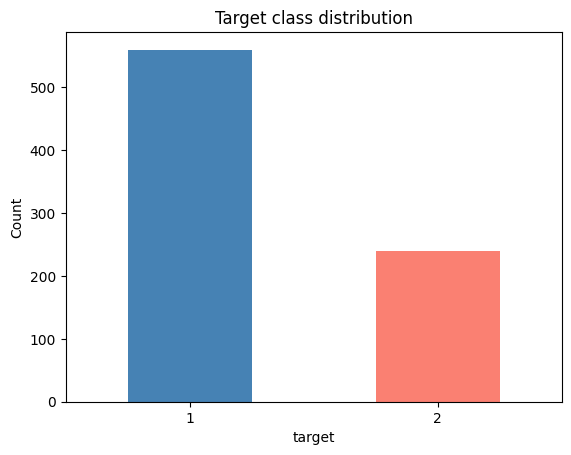

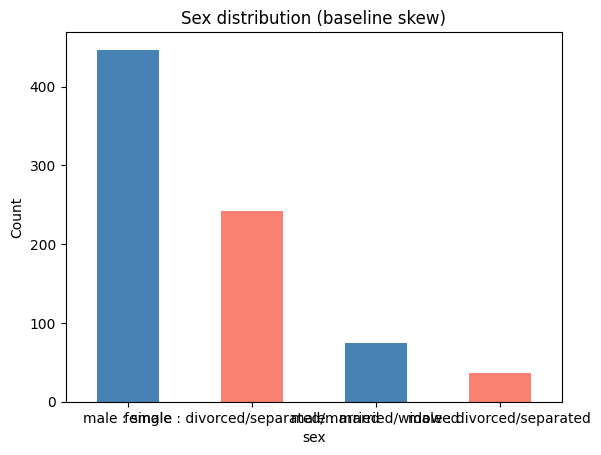

Sex distribution (%):
sex
male : single                          55.9
female : divorced/separated/married    30.2
male : married/widowed                  9.4
male : divorced/separated               4.5
Name: proportion, dtype: float64


In [15]:
# Class imbalance visualization
train_real["target"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target class distribution") #remove title for latex(use latex caption, begin)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Sex distribution skew
train_real["sex"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Sex distribution (baseline skew)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Sex distribution (%):")
print(train_real["sex"].value_counts(normalize=True).round(3) * 100)

Age group distribution:
age_group
adult (≥25)    682
young (<25)    118
Name: count, dtype: int64


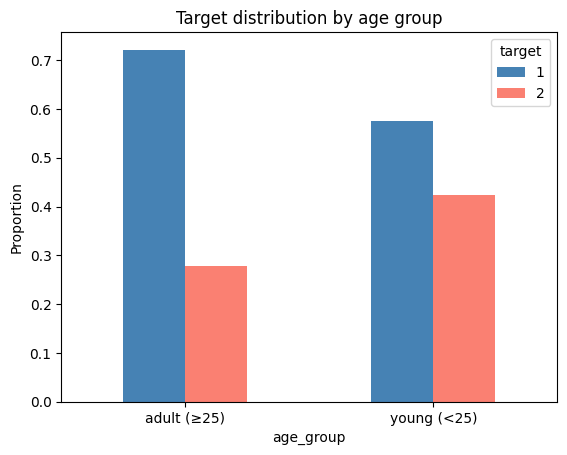

In [16]:
# Binarize age for fairness metric alignment where less than 25 is considered Young
train_real["age_group"] = (train_real["age"] < 25).map({True: "young (<25)", False: "adult (≥25)"})

print("Age group distribution:")
print(train_real["age_group"].value_counts())

pd.crosstab(train_real["age_group"], train_real["target"], normalize="index") \
    .plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target distribution by age group")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Summary statistics split by sensitive group
print("=== Mean numeric features by sex ===")
print(train_real.groupby("sex")[["credit_amount", "duration_months", "age"]].mean().round(2))

print("\n=== Mean numeric features by age group ===")
print(train_real.groupby("age_group")[["credit_amount", "duration_months"]].mean().round(2))

=== Mean numeric features by sex ===
                                     credit_amount  duration_months    age
sex                                                                       
female : divorced/separated/married        2838.67            19.55  32.90
male : divorced/separated                  3503.19            20.83  38.67
male : married/widowed                     2068.04            17.89  30.65
male : single                              3649.39            22.07  37.76

=== Mean numeric features by age group ===
             credit_amount  duration_months
age_group                                  
adult (≥25)        3277.10            20.89
young (<25)        3088.75            20.69


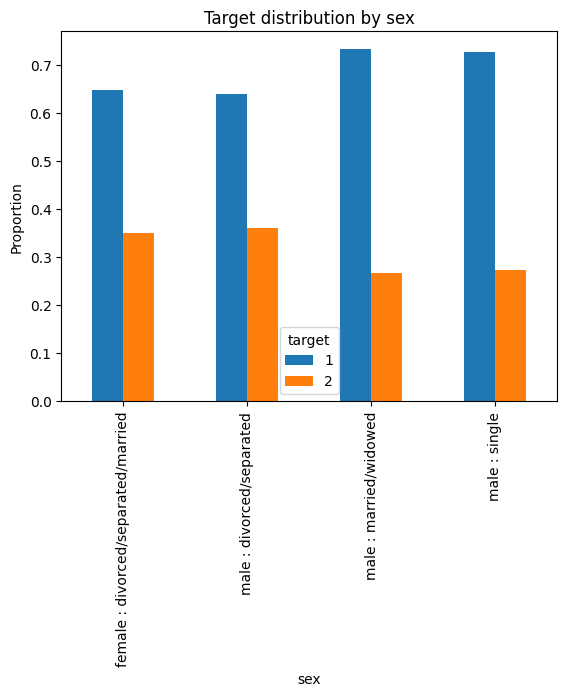

In [18]:
pd.crosstab(train_real["sex"], train_real["target"], normalize="index") \
    .plot(kind="bar")

plt.title("Target distribution by sex")
plt.ylabel("Proportion")
plt.show()

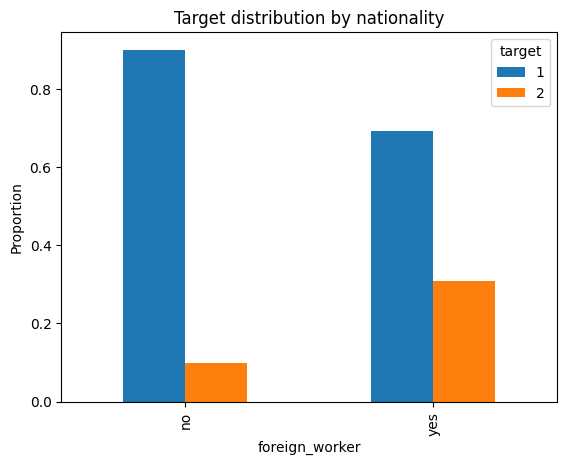

In [19]:
# split based on nationalty
pd.crosstab(train_real["foreign_worker"], train_real["target"], normalize="index") \
    .plot(kind="bar")

plt.title("Target distribution by nationality")
plt.ylabel("Proportion")
plt.show()

<Axes: xlabel='job'>

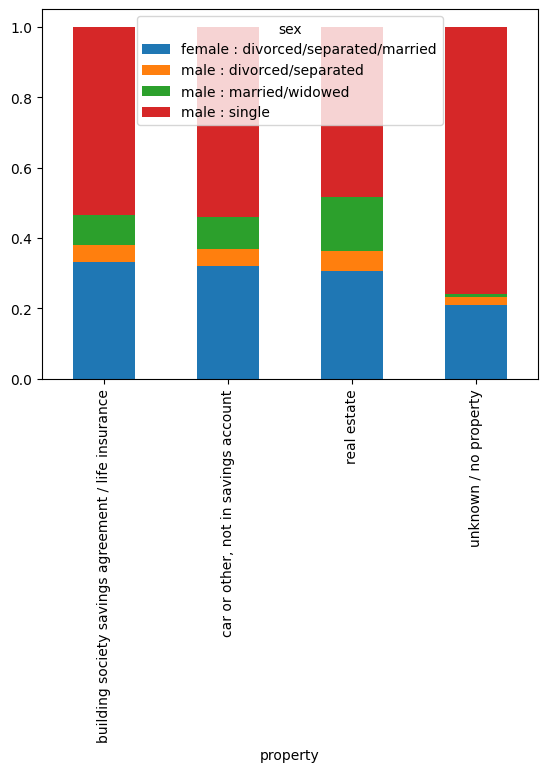

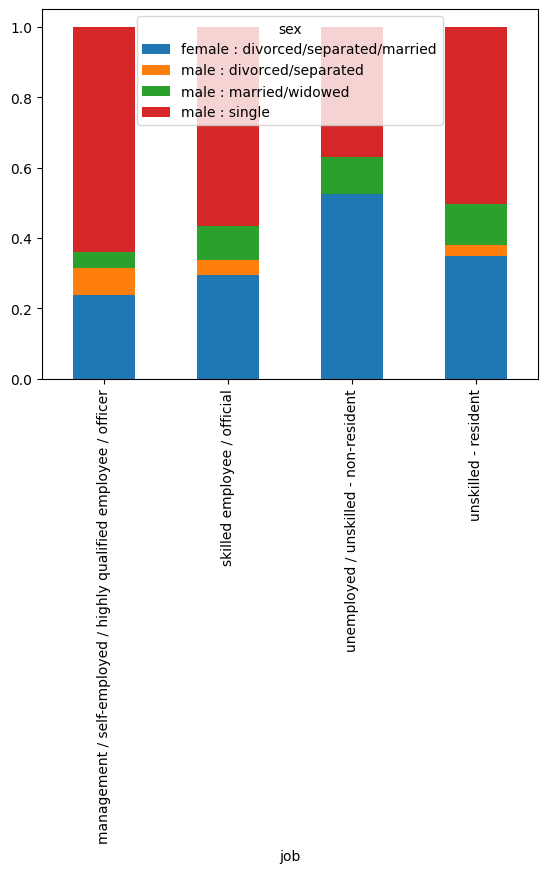

In [20]:
pd.crosstab(train_real["property"], train_real["sex"], normalize="index")
pd.crosstab(train_real["property"], train_real["sex"], normalize="index").plot(kind="bar", stacked=True)
pd.crosstab(train_real["job"], train_real["sex"], normalize="index")
pd.crosstab(train_real["job"], train_real["sex"], normalize="index").plot(kind="bar", stacked=True)

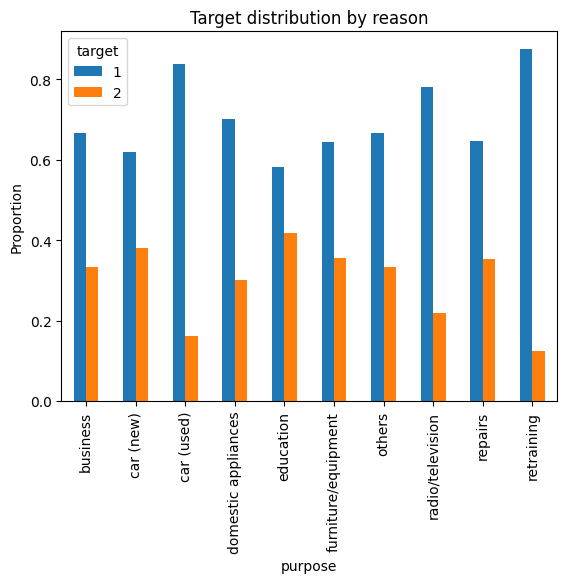

In [21]:
pd.crosstab(train_real["purpose"], train_real["target"], normalize="index") \
    .plot(kind="bar")

plt.title("Target distribution by reason")
plt.ylabel("Proportion")
plt.show()

<Axes: title={'center': 'duration_months'}, xlabel='target'>

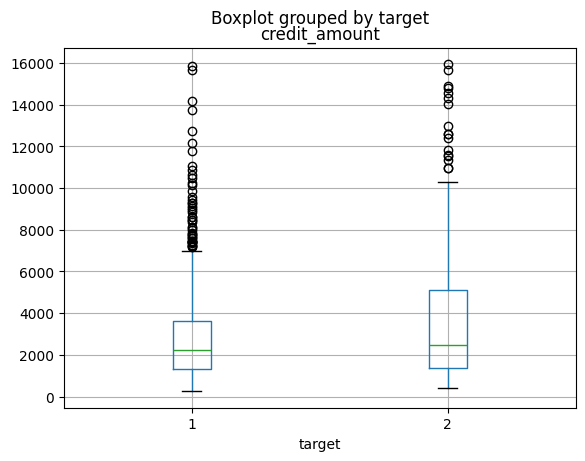

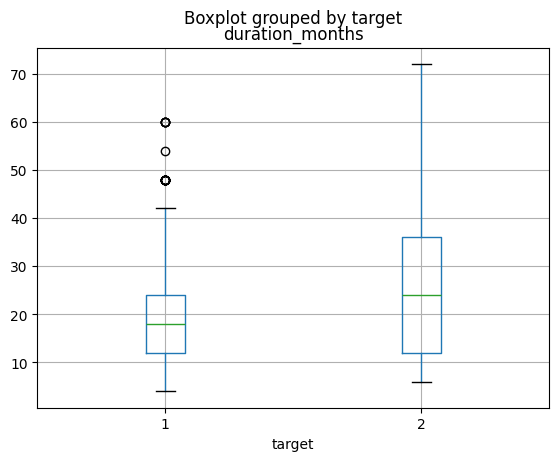

In [22]:
# financial side(nothing to see)
train_real.boxplot(column="credit_amount", by="target")
train_real.boxplot(column="duration_months", by="target")

In [ ]:
# Cramér's V between categorical features and sensitive attributes
# from scipy.stats import chi2_contingency
# import numpy as np

# def cramers_v(x, y):
#     ct = pd.crosstab(x, y)
#     chi2 = chi2_contingency(ct)[0]
#     n = ct.sum().sum()
#     r, k = ct.shape
#     return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# cat_cols = ["credit_history", "purpose", "checking_account_status",
#             "savings_account", "employment_duration", "property"]

# print("Cramér's V with sex:")
# for col in cat_cols:
#     print(f"  {col}: {cramers_v(train_real[col], train_real['sex']):.3f}")

# print("\nCramér's V with age_group:")
# for col in cat_cols:
#     print(f"  {col}: {cramers_v(train_real[col], train_real['age_group']):.3f}")

# # Point-biserial correlation for numeric features vs age (continuous)
# from scipy.stats import pointbiserialr
# num_cols = ["credit_amount", "duration_months", "installment_rate"]
# sex_binary = (train_real["sex"] == "male").astype(int)

# print("\nPoint-biserial correlation with sex (binary):")
# for col in num_cols:
#     r, p = pointbiserialr(sex_binary, train_real[col])
#     print(f"  {col}: r={r:.3f}, p={p:.3f}")

Cramér's V with sex:
  credit_history: 0.123
  purpose: 0.129
  checking_account_status: 0.043
  savings_account: 0.047
  employment_duration: 0.240
  property: 0.103

Cramér's V with age_group:
  credit_history: 0.191
  purpose: 0.164
  checking_account_status: 0.160
  savings_account: 0.060
  employment_duration: 0.211
  property: 0.097

Point-biserial correlation with sex (binary):
  credit_amount: r=0.075, p=0.033
  duration_months: r=0.080, p=0.023
  installment_rate: r=0.106, p=0.003


In [ ]:
# # Synthetic dataset generation(The one that worked so far)
# synthesizer = CTGANSynthesizer(
#     metadata,
#     epochs=1000,
#     embedding_dim=512,
#     batch_size=128,
#     discriminator_steps=5,
#     generator_lr=1e-4,
#     discriminator_lr=2e-4,
#     verbose=True,
#     pac=1 # Added pac=1 to fix the AssertionError
# )
# synthesizer.fit(train_data)
# synthesizer = synthesizer.sample(num_rows=len(train_data))
# fig = synthesizer.get_loss_values_plot()
# fig.show()